# 07 · Human-on-the-loop · **Time travel**

**Idea:** Every step of a run is saved as a **checkpoint**. You can:

| Action | Method | Use it to… |
|---|---|---|
| **Inspect** history | `graph.get_state_history(config)` | Debug "why did it do that?" |
| **Replay** | `graph.invoke(None, old_checkpoint_config)` | Re-run from a past step (e.g. after a flaky LLM call) |
| **Fork** | `graph.update_state(old_checkpoint_config, {...})` then invoke | "What if the topic had been X?" — edits create a *new branch*, original history is kept |

```
START -> pick_topic -> write_joke -> explain_joke -> END     (checkpoint saved after each node)
```

In [1]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

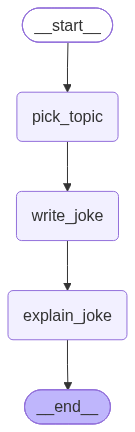

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    topic: str
    joke: str
    explanation: str

def pick_topic(state: State):
    t = small_llm.invoke("Name ONE random animal. Reply with just the animal name.").content.strip()
    return {"topic": t}

def write_joke(state: State):
    j = small_llm.invoke(f"Write a one-line joke about: {state['topic']}").content
    return {"joke": j}

def explain_joke(state: State):
    e = small_llm.invoke(f"Explain this joke in one sentence: {state['joke']}").content
    return {"explanation": e}

builder = StateGraph(State)
builder.add_node("pick_topic", pick_topic)
builder.add_node("write_joke", write_joke)
builder.add_node("explain_joke", explain_joke)
builder.add_edge(START, "pick_topic")
builder.add_edge("pick_topic", "write_joke")
builder.add_edge("write_joke", "explain_joke")
builder.add_edge("explain_joke", END)
graph = builder.compile(checkpointer=InMemorySaver())
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

### 1 · Run normally

In [4]:
config = {"configurable": {"thread_id": "tt-1"}}
first = graph.invoke({}, config)
print("topic:", first["topic"]); print("joke :", first["joke"])

topic: elephant
joke : "Elephant, you're the one who's eating the grass!"


### 2 · Inspect the history (newest first)

In [7]:
history = list(graph.get_state_history(config))
for snap in history:
    print(f"step={snap.metadata['step']:>2}  next={str(snap.next):<18} topic={snap.values.get('topic')!r}")

step= 3  next=()                 topic='elephant'
step= 2  next=('explain_joke',)  topic='elephant'
step= 1  next=('write_joke',)    topic='elephant'
step= 0  next=('pick_topic',)    topic=None
step=-1  next=('__start__',)     topic=None


### 3 · Replay
Pick the checkpoint whose `next` is `write_joke` (i.e. *after* the topic was chosen).
Replaying **does not re-run `pick_topic`** (its result is already saved) — only the later nodes run again,
so we get a *new joke on the same topic*.

In [10]:
before_joke = next(s for s in history if s.next == ("write_joke",))
print("Replaying from:", before_joke.config["configurable"]["checkpoint_id"])

replayed = graph.invoke(None, before_joke.config)     # None = "no new input, just continue from here"
print("topic :", replayed["topic"], "(unchanged)")
print("joke  :", replayed["joke"], "(re-generated)")

Replaying from: 1f1bd9e1-259b-612a-8001-e3b75864b4a0
topic : elephant (unchanged)
joke  : "Elephant, you're the one who's eating the grass!" (re-generated)


### 4 · Fork: edit the past and branch
`update_state` writes a **new checkpoint** with our edit. Running from it continues down a new timeline.

In [11]:
fork_config = graph.update_state(before_joke.config, {"topic": "penguin"})   # human overrides the topic
forked = graph.invoke(None, fork_config)
print("topic      :", forked["topic"])
print("joke       :", forked["joke"])
print("explanation:", forked["explanation"])

topic      : penguin
joke       : Penguin on a log.
explanation: Penguin on a log is a joke that plays on the fact that a log is a piece of wood, and a log can be a log. The joke is that the log is a log, and the penguin is on it.


### Why this matters
Combine with notebook 05: a reviewer sees a bad intermediate result, **rewinds**, fixes one field,
and lets the agent carry on — no need to restart the whole run.